# $\mathrm{Na}_{\mathrm{V}}1.5$ IFM-engagement analysis

This notebook compares two IFM-engagement coordinates across WT, the **IFM→QQQ fast-inactivation mutant**, and the available masking strategies. QQQ replaces canonical I1485-F1486-M1487 with Q1485-Q1486-Q1487; it is not a selectivity-filter mutation. The contact definitions below are explicit because the original figure labels (`IFM1` and `IFM2`) do not encode their residue pairs. The expanded 3 Å-filtered CSVs provide the central motif residue (F1486 in WT; Q1486 in QQQ) against N1659 and N1765.

`masked v2 no-IFM` retains the native IFM sequence and excludes the IFM residues from the masked region; it therefore preserves IFM-site MSA information. It does not mean that the IFM sequence was removed. The other masked profiles and the QQQ profiles should be interpreted according to their distinct MSA masks.


In [1]:
from pathlib import Path
import sys
import csv, re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

repo_root = Path.cwd() if (Path.cwd() / 'shared').is_dir() else Path.cwd().parent
sys.path.insert(0, str(repo_root)) if str(repo_root) not in sys.path else None
from scripts.ensemble_rmsf_analysis.io import read_csv_resolving_lfs
SUBSET = 'all_ok_3'  # Corrected 3 Å suffix; alternatives: 'all', 'all_ok', 'first_converged', or 'first_100_generated'.
from shared.plotting import NAV15_PALETTE
CONDITION_COLORS = {'WT': NAV15_PALETTE['WT_VAN'], 'QQQ': NAV15_PALETTE['QQQ_VAN']}
ENSEMBLE_COLORS = {
    'WT | vanilla': NAV15_PALETTE['WT_VAN'],
    'WT | masked': NAV15_PALETTE['WT_HM'],
    'WT | masked v2': NAV15_PALETTE['WT_MASKED_V2'],
    'WT | masked v2 no-IFM': NAV15_PALETTE['WT_MASKED_V2_NOIFM'],
    'QQQ | vanilla': NAV15_PALETTE['QQQ_VAN'],
    'QQQ | masked': NAV15_PALETTE['QQQ_MASKED'],
    'QQQ | masked v2': NAV15_PALETTE['QQQ_MASKED_V2'],
}
ENGAGEMENT_THRESHOLD_A = 12.0
ENGAGEMENT_STATE_NOTE = 'Geometric classification: both contacts ≤12 Å = engaged; one contact ≤12 Å = partially engaged; both contacts >12 Å = disengaged.'

# Optional local directories containing the AF2 PDBs. Leave as None to use manifest paths.
# Example: PDB_ROOT_OVERRIDES[('QQQ','masked')] = Path('/path/to/qqq/masked')
PDB_ROOT_OVERRIDES = {key: None for key in [('WT','vanilla'),('WT','masked'),('QQQ','vanilla'),('QQQ','masked')]}

# Contact identities remain hypotheses, but the construct numbering below is
# sequence-verified against 8VYJ, 8VYK, 7DTC, 8T6L, and 6UZ3.
# Canonical 1485-1487/1659/1765 map to model 1169-1171/1343/1449.
# Distances are C-alpha to C-alpha. Change either residue tuple and rerun all cells.
IFM_CONTACT_DEFINITIONS_ARE_GUESSED = True
CONSTRUCT_NUMBERING_IS_SEQUENCE_VERIFIED = True
IFM_CONTACT_ALIASES = {
    'IFM1': {
        'display_alias': 'IFM/QQQ central residue–N1659 (model F/Q1170–N1343)',
        'WT': (('PHE', 1170), ('ASN', 1343)),
        'QQQ': (('GLN', 1170), ('ASN', 1343)),
        'WT_csv_column': 'CA_PHE1170_CA-ASN1343_CA',
        'QQQ_csv_column': 'CA_GLN1170_CA-ASN1343_CA',
        'interpretation': 'central inactivation-motif residue to DIV receptor-site N1659',
    },
    'IFM2': {
        'display_alias': 'IFM/QQQ central residue–N1765 (model F/Q1170–N1449)',
        'WT': (('PHE', 1170), ('ASN', 1449)),
        'QQQ': (('GLN', 1170), ('ASN', 1449)),
        'WT_csv_column': 'CA_PHE1170_CA-ASN1449_CA',
        'QQQ_csv_column': 'CA_GLN1170_CA-ASN1449_CA',
        'interpretation': 'central inactivation-motif residue to distal intracellular N1765',
    },
}
IFM_CONTACT_ALIASES


{'IFM1': {'display_alias': 'IFM/QQQ central residue–N1659 (model F/Q1170–N1343)',
  'WT': (('PHE', 1170), ('ASN', 1343)),
  'QQQ': (('GLN', 1170), ('ASN', 1343)),
  'WT_csv_column': 'CA_PHE1170_CA-ASN1343_CA',
  'QQQ_csv_column': 'CA_GLN1170_CA-ASN1343_CA',
  'interpretation': 'central inactivation-motif residue to DIV receptor-site N1659'},
 'IFM2': {'display_alias': 'IFM/QQQ central residue–N1765 (model F/Q1170–N1449)',
  'WT': (('PHE', 1170), ('ASN', 1449)),
  'QQQ': (('GLN', 1170), ('ASN', 1449)),
  'WT_csv_column': 'CA_PHE1170_CA-ASN1449_CA',
  'QQQ_csv_column': 'CA_GLN1170_CA-ASN1449_CA',
  'interpretation': 'central inactivation-motif residue to distal intracellular N1765'}}

In [2]:
from shared.presentation_export import install_notebook_figure_export
WRITING_FIGURE_DIR = repo_root.parent / 'vgci_mutants_writing' / 'figures' / 'nav15'
install_notebook_figure_export(WRITING_FIGURE_DIR, 'Nav15_IFM_engagement_analysis')


PosixPath('/Users/ahernandezgonzalez/Repositories/vgci_mutants_writing/figures/nav15/Nav15_IFM_engagement_analysis')

## Dataset paths and subset selection


In [3]:
from shared.dataset_selection import select_manifest_rows

MANIFESTS = {
    ('WT','vanilla'): repo_root/'nav15/rmsd_convergence_filtering/Nav15_rmsd_convergence_wt_vanilla/all_models_manifest.csv',
    ('WT','masked'): repo_root/'nav15/rmsd_convergence_filtering/Nav15_rmsd_convergence_wt_masked/all_models_manifest.csv',
    ('QQQ','vanilla'): repo_root/'nav15/rmsd_convergence_filtering/Nav15_rmsd_convergence_qqq_vanilla/all_models_manifest.csv',
    ('QQQ','masked'): repo_root/'nav15/rmsd_convergence_filtering/Nav15_rmsd_convergence_qqq_masked_v2/all_models_manifest.csv',
}


path_audit = pd.DataFrame([{'condition': c, 'protocol': p, 'manifest': str(path), 'exists': path.is_file()} for (c,p),path in MANIFESTS.items()])
display(path_audit)
assert path_audit['exists'].all(), 'A required RMSD manifest is missing.'

# The expanded 3 Å tables contain both sequence-verified IFM coordinates.
DISTANCE_CSVS = {
    'WT | vanilla': repo_root/'nav15/dataDistances/26-07-27_Nav15_wt_vanillaAF2_distances_all_ok_rmsd_3A.csv',
    'WT | masked': repo_root/'nav15/dataDistances/26-07-25_Nav15_wt_masked_AF2_distances_extra_ifm_all_ok_rmsd_3A.csv',
    'WT | masked v2': repo_root/'nav15/dataDistances/26-07-27_Nav15_wt_maskedv2_AF2_distances_all_ok_rmsd_3A.csv',
    'WT | masked v2 no-IFM': repo_root/'nav15/dataDistances/26-07-27_Nav15_wt_maskedv2_noIFM_AF2_distances_all_ok_rmsd_3A.csv',
    'QQQ | vanilla': repo_root/'nav15/dataDistances/26-07-27_Nav15_qqq_vanilla_AF2_distances_all_ok_rmsd_3A.csv',
    'QQQ | masked': repo_root/'nav15/dataDistances/26-07-27_Nav15_qqq_masked_AF2_distances_all_ok_rmsd_3A.csv',
    'QQQ | masked v2': repo_root/'nav15/dataDistances/26-07-27_Nav15_qqq_maskedv2_AF2_distances_all_ok_rmsd_3A.csv',
}
required_tokens = ('1169','1170','1171','1343','1449')
precomputed_audit = []
for ensemble, path in DISTANCE_CSVS.items():
    header = read_csv_resolving_lfs(path, repo_root, nrows=0).columns.tolist()
    matches = [column for column in header if any(token in column.upper() for token in required_tokens)]
    precomputed_audit.append({'ensemble': ensemble, 'csv': path.name, 'columns': len(header), 'IFM_related_columns': matches})
display(pd.DataFrame(precomputed_audit))


,condition,protocol,manifest,exists
0,WT,vanilla,/Users/ahernandezgonzalez/Repositories/vgci_mu...,True
1,WT,masked,/Users/ahernandezgonzalez/Repositories/vgci_mu...,True
2,QQQ,vanilla,/Users/ahernandezgonzalez/Repositories/vgci_mu...,True
3,QQQ,masked,/Users/ahernandezgonzalez/Repositories/vgci_mu...,True


,ensemble,csv,columns,IFM_related_columns
0,WT | vanilla,26-07-27_Nav15_wt_vanillaAF2_distances_all_ok_...,1015,"[shortest_LYS1161-ASN1343, shortest_LYS1162-AS..."
1,WT | masked,26-07-25_Nav15_wt_masked_AF2_distances_extra_i...,5,"[shortest_PHE1170-ASN1343, shortest_PHE1170-AS..."
2,WT | masked v2,26-07-27_Nav15_wt_maskedv2_AF2_distances_all_o...,1015,"[shortest_LYS1161-ASN1343, shortest_LYS1162-AS..."
3,WT | masked v2 no-IFM,26-07-27_Nav15_wt_maskedv2_noIFM_AF2_distances...,1015,"[shortest_LYS1161-ASN1343, shortest_LYS1162-AS..."
4,QQQ | vanilla,26-07-27_Nav15_qqq_vanilla_AF2_distances_all_o...,1015,"[shortest_LYS1161-ASN1343, shortest_LYS1162-AS..."
5,QQQ | masked,26-07-27_Nav15_qqq_masked_AF2_distances_all_ok...,1015,"[shortest_LYS1161-ASN1343, shortest_LYS1162-AS..."
6,QQQ | masked v2,26-07-27_Nav15_qqq_maskedv2_AF2_distances_all_...,1015,"[shortest_LYS1161-ASN1343, shortest_LYS1162-AS..."


## Load IFM coordinates from the expanded 3 Å distance tables


In [4]:
from shared.structure_distances import read_ca_residues as ca_atoms

from functools import partial
from shared.nav15_latching import (
    calculate_contacts as _calculate_contacts,
    resolve_pdb_path as _resolve_pdb_path,
)
calculate_contacts = partial(
    _calculate_contacts, contact_aliases=IFM_CONTACT_ALIASES,
)
resolve_pdb_path = partial(
    _resolve_pdb_path, root_overrides=PDB_ROOT_OVERRIDES,
)


frames = []
for ensemble, path in DISTANCE_CSVS.items():
    condition, protocol = [part.strip() for part in ensemble.split('|', 1)]
    source = read_csv_resolving_lfs(path, repo_root)
    prefix = 'PHE' if condition == 'WT' else 'GLN'
    contact_columns = {
        'IFM1': f'CA_{prefix}1170_CA-ASN1343_CA',
        'IFM2': f'CA_{prefix}1170_CA-ASN1449_CA',
    }
    missing = [column for column in contact_columns.values() if column not in source.columns]
    if missing:
        raise KeyError(f'{ensemble}: missing IFM engagement columns {missing}')
    frame = source[['pdb_file', *contact_columns.values()]].rename(columns={value: key for key, value in contact_columns.items()})
    frame.insert(0, 'Protocol', protocol)
    frame.insert(0, 'Condition', condition)
    frame.insert(0, 'Ensemble', ensemble)
    frames.append(frame)
ifm_df = pd.concat(frames, ignore_index=True)
availability = (ifm_df.groupby(['Ensemble','Condition','Protocol']).agg(models=('pdb_file','size'), IFM1=('IFM1','count'), IFM2=('IFM2','count')).reset_index())
display(availability)
DATA_READY = ifm_df[['IFM1','IFM2']].notna().all(axis=1).any()
assert DATA_READY, 'No complete IFM engagement coordinates were loaded.'
short_1 = ifm_df['IFM1'].le(ENGAGEMENT_THRESHOLD_A)
short_2 = ifm_df['IFM2'].le(ENGAGEMENT_THRESHOLD_A)
ifm_df['Engagement geometry'] = np.select(
    [short_1 & short_2, short_1 ^ short_2],
    ['Engaged', 'Partially engaged'],
    default='Disengaged',
)
engagement_summary = (ifm_df.groupby(['Ensemble','Engagement geometry']).size().unstack(fill_value=0))
engagement_summary = (100 * engagement_summary.div(engagement_summary.sum(axis=1), axis=0)).round(1)
engagement_summary.columns = [f'{column} (%)' for column in engagement_summary.columns]
display(engagement_summary)
print(ENGAGEMENT_STATE_NOTE)


,Ensemble,Condition,Protocol,models,IFM1,IFM2
0,QQQ | masked,QQQ,masked,4999,4999,4999
1,QQQ | masked v2,QQQ,masked v2,5000,5000,5000
2,QQQ | vanilla,QQQ,vanilla,5000,5000,5000
3,WT | masked,WT,masked,5500,5500,5500
4,WT | masked v2,WT,masked v2,4999,4999,4999
5,WT | masked v2 no-IFM,WT,masked v2 no-IFM,5000,5000,5000
6,WT | vanilla,WT,vanilla,5000,5000,5000


,Disengaged (%),Engaged (%),Partially engaged (%)
Ensemble,,,
QQQ | masked,99.9,0.0,0.1
QQQ | masked v2,99.7,0.0,0.3
QQQ | vanilla,94.7,0.0,5.3
WT | masked,99.5,0.0,0.5
WT | masked v2,96.7,0.0,3.3
WT | masked v2 no-IFM,97.7,0.0,2.3
WT | vanilla,42.5,0.1,57.4


Geometric classification: both contacts ≤12 Å = engaged; one contact ≤12 Å = partially engaged; both contacts >12 Å = disengaged.


## IFM-engagement joint distributions

IFM1 reports the central IFM/QQQ residue to N1659 contact, and IFM2 reports the corresponding contact to N1765. The experimental overlay includes structures in which the canonical IFM coordinates are resolved: 8VYJ, 8VYK, 7DTC, 8T6L, and 6UZ3. These span native full-length open, intermediate-inactivated, and toxin-stabilized comparators, but all retain a receptor-proximal IFM geometry by these two coordinates. The engineered 7FBS QQQ linker is unresolved and is therefore not assigned fabricated distances. The 12 Å guide marks a descriptive engaged contact region; these two coordinates alone do not establish a functional gating state. Each panel reports the fraction and count of its plotted final-QC models for which both IFM1 and IFM2 are at or below 12 Å.


In [5]:
import importlib
import shared.nav15_latching as nav15_latching
importlib.reload(nav15_latching)
_plot_ifm_joint = nav15_latching.plot_ifm_joint


## Experimental validation and explicit distances


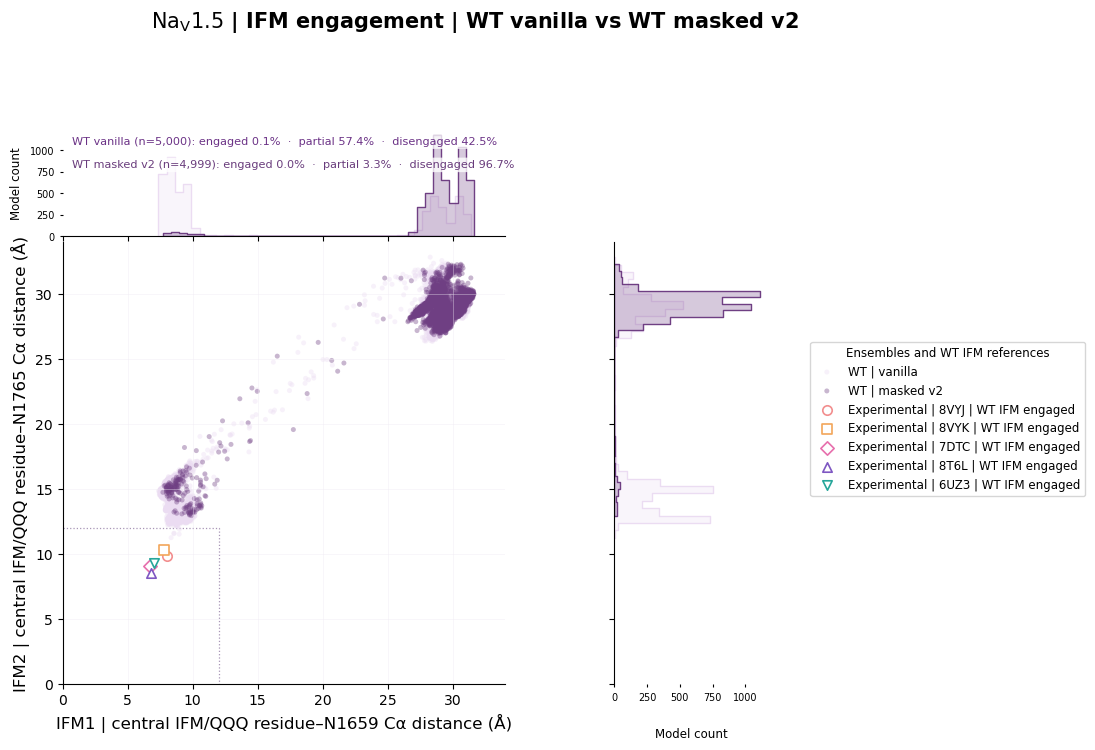

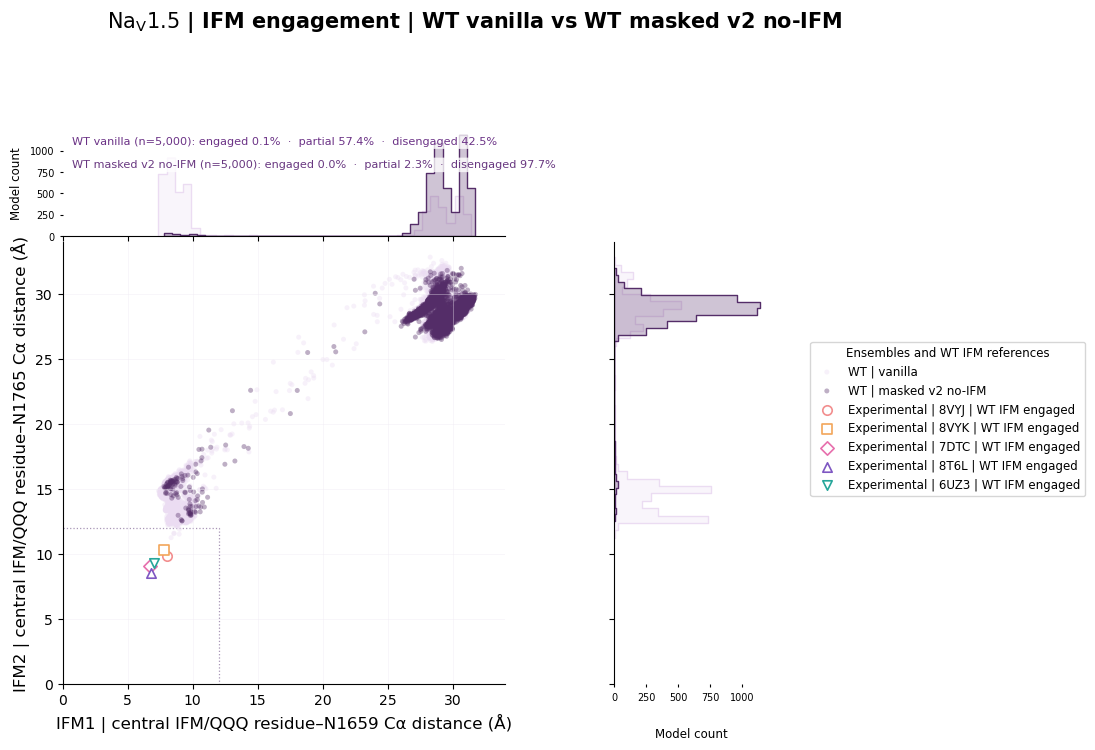

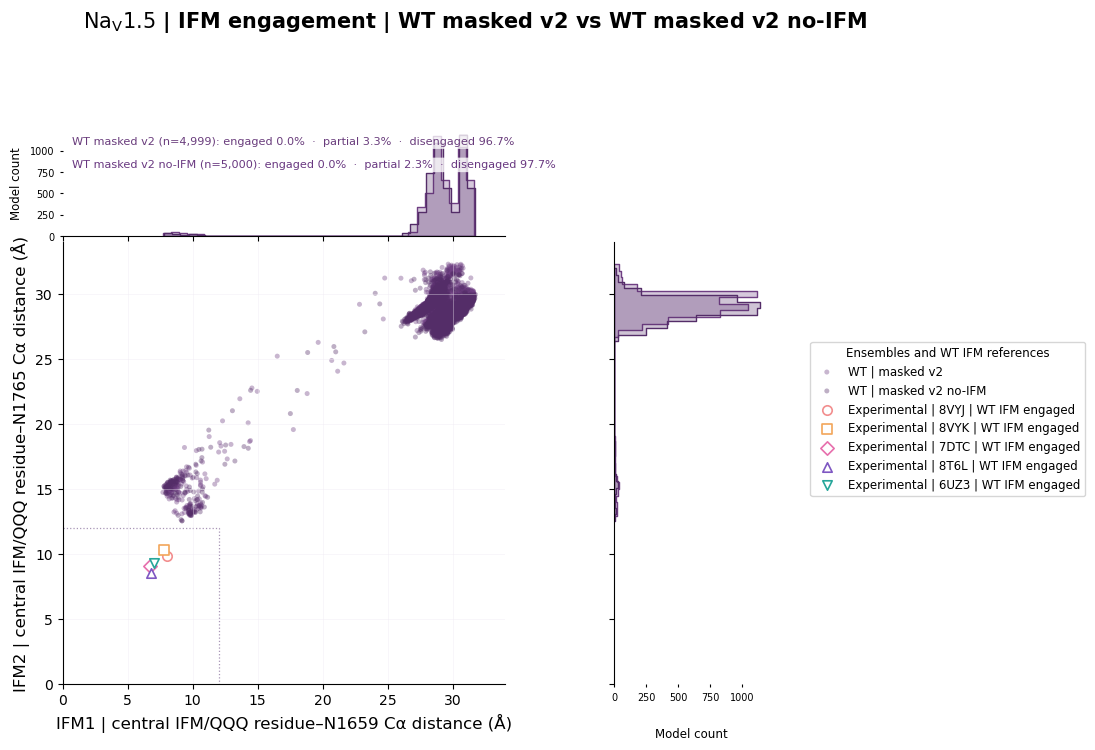

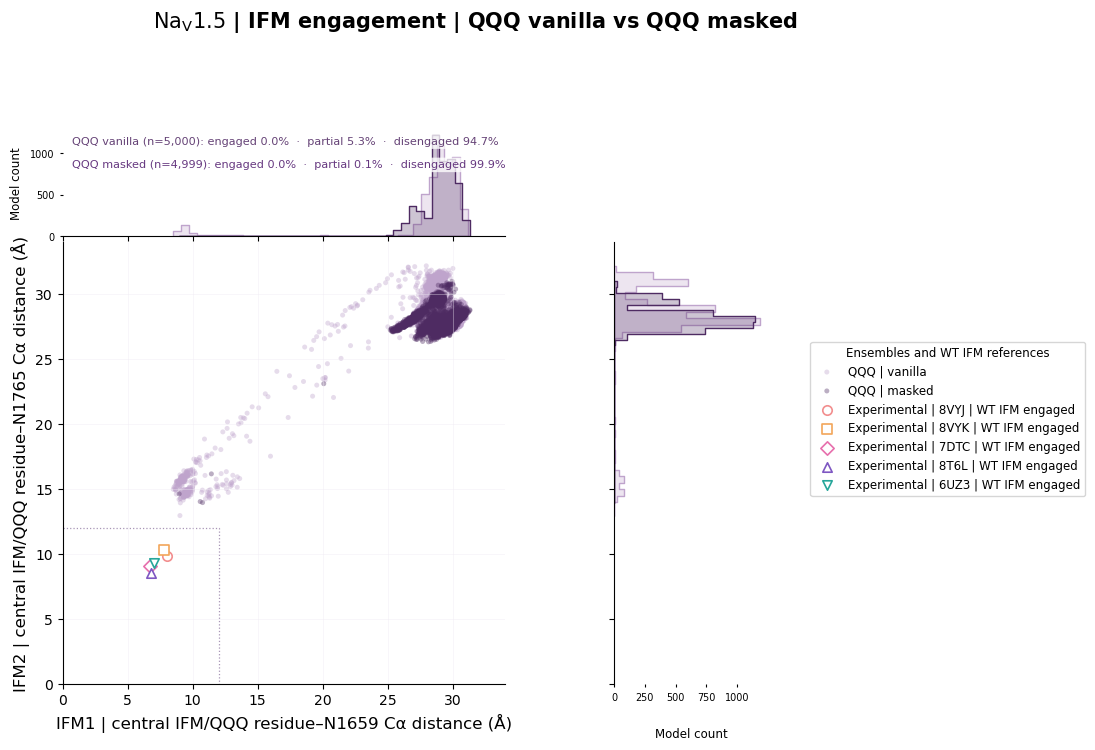

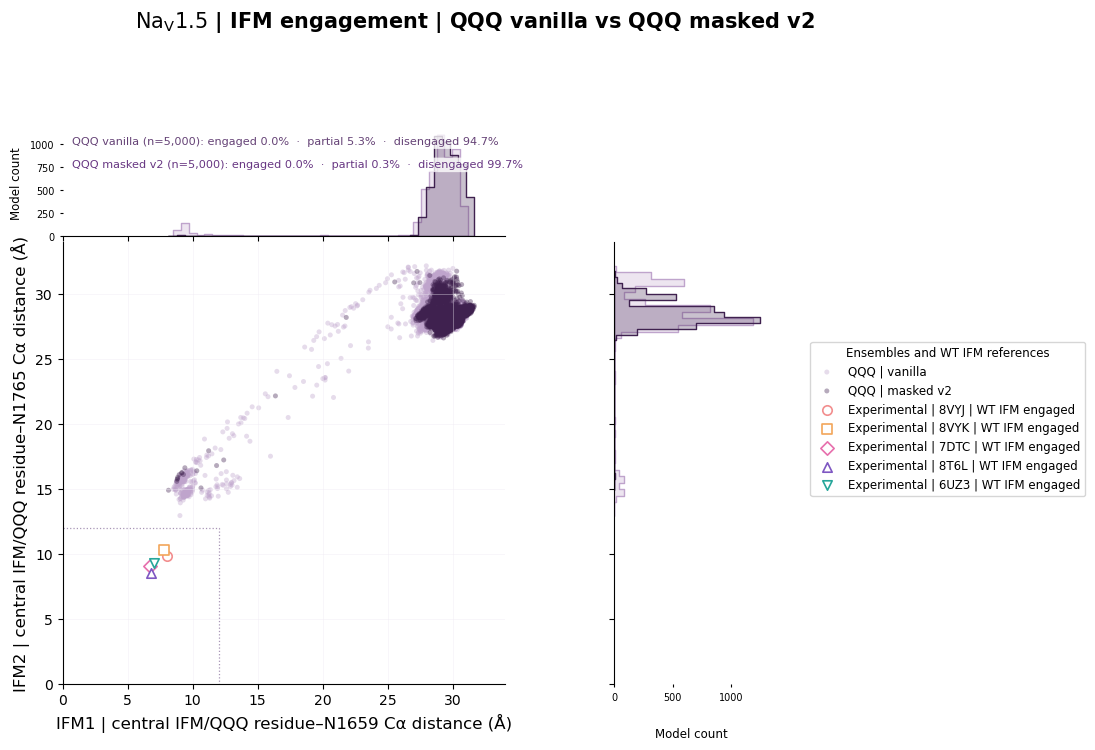

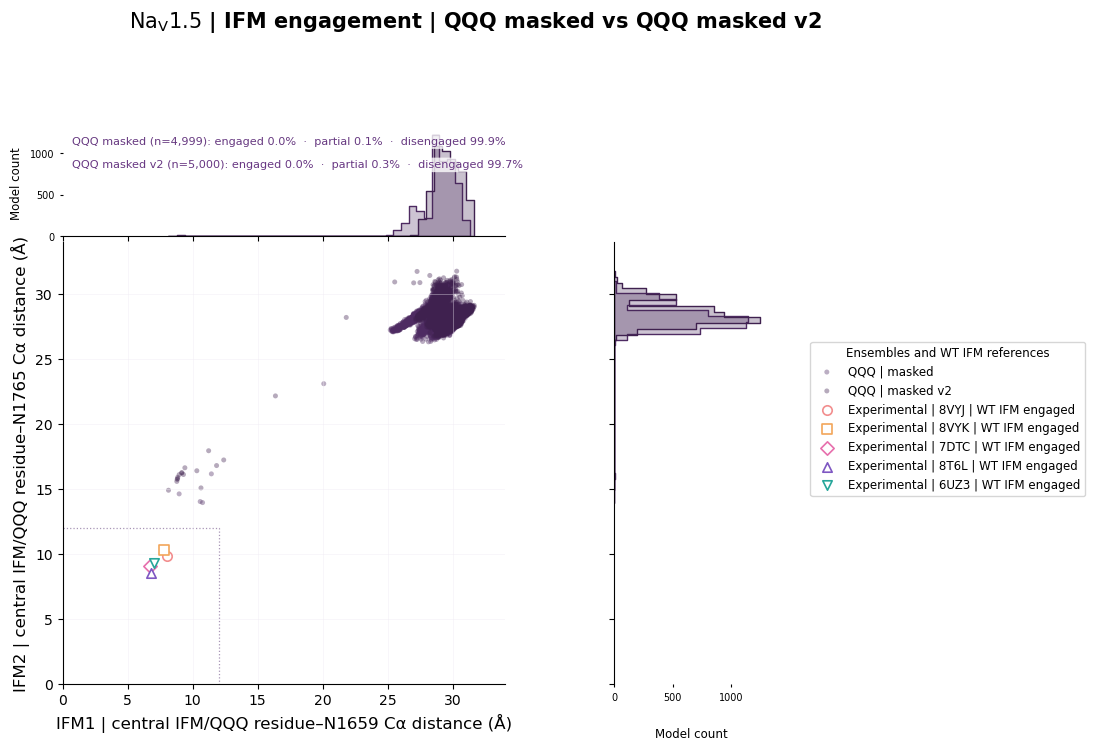

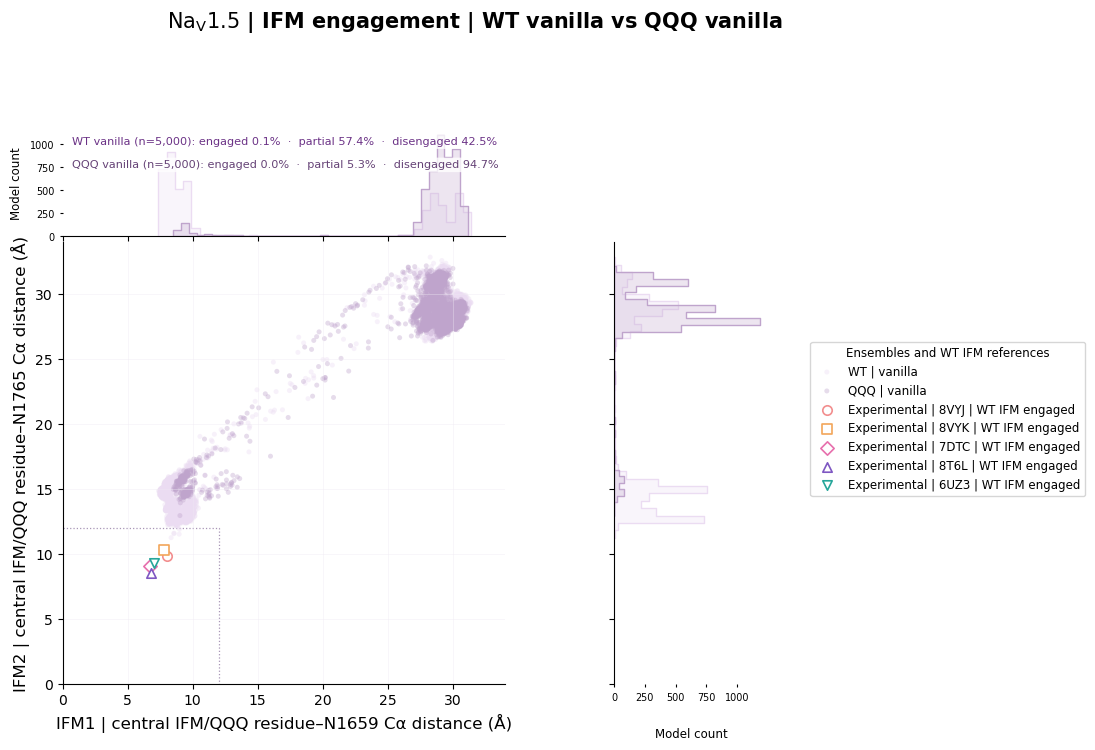

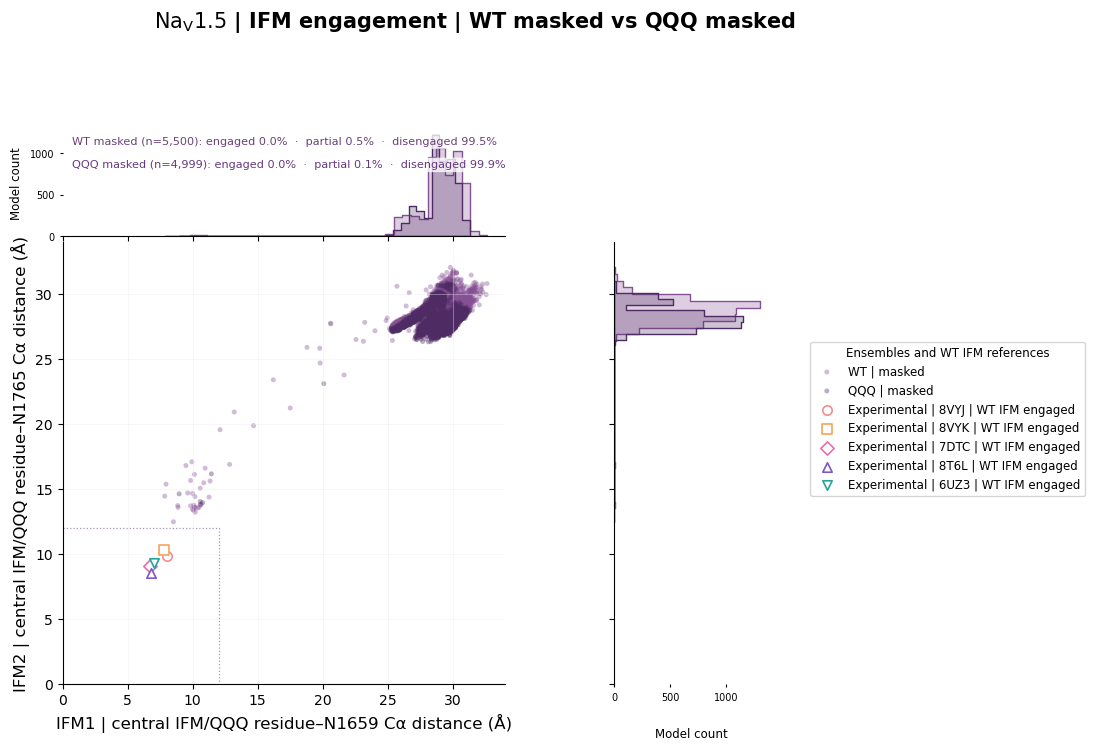

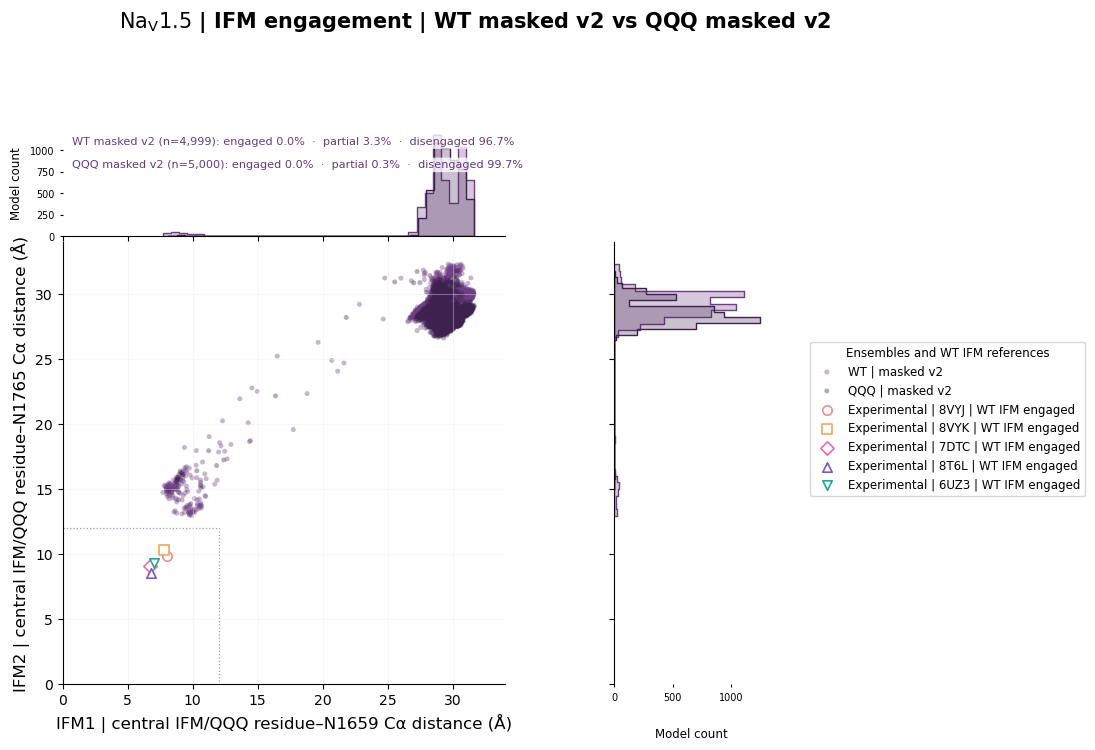

In [6]:
# Human 8VYJ/8VYK/7DTC use canonical numbering. Rat 6UZ3/8T6L are shifted +2.
EXPERIMENTAL_RESIDUE_MAP = {
    '8VYJ': {'IFM1': (('PHE',1486),('ASN',1659)), 'IFM2': (('PHE',1486),('ASN',1765))},
    '8VYK': {'IFM1': (('PHE',1486),('ASN',1659)), 'IFM2': (('PHE',1486),('ASN',1765))},
    '7DTC': {'IFM1': (('PHE',1486),('ASN',1659)), 'IFM2': (('PHE',1486),('ASN',1765))},
    '8T6L': {'IFM1': (('PHE',1488),('ASN',1661)), 'IFM2': (('PHE',1488),('ASN',1767))},
    '6UZ3': {'IFM1': (('PHE',1488),('ASN',1661)), 'IFM2': (('PHE',1488),('ASN',1767))},
}
EXPERIMENTAL_STRUCTURE_CONTEXT = {
    '8VYJ': 'full-length human Nav1.5 Class-I open state',
    '8VYK': 'full-length human Nav1.5 Class-II more-expanded open state',
    '7DTC': 'human Nav1.5-E1784K intermediate-inactivated structure',
    '8T6L': 'rat Nav1.5 with BTX-B; optional toxin-stabilized open comparator',
    '7FBS': 'rat Nav1.5c/QQQ engineered open structure; IFM/QQQ coordinates unresolved',
    '6UZ3': 'rat Nav1.5 reference structure',
}
UNRESOLVED_EXPERIMENTAL_IFM = {
    '7FBS': 'The engineered QQQ/III–IV-linker segment is not modeled at the canonical motif positions; IFM1 and IFM2 cannot be calculated.',
}

from functools import partial
from shared.nav15_latching import (
    explicit_experimental_distances as _explicit_experimental_distances,
    plot_missing_af2_panel as _plot_missing_af2_panel,
)
explicit_experimental_distances = partial(
    _explicit_experimental_distances, repo_root=repo_root,
    residue_map=EXPERIMENTAL_RESIDUE_MAP,
)

# Explicit editable values (Å), calculated from the residue map above.
EXPERIMENTAL_IFM_DISTANCES = {
    '8VYJ': {'IFM1': 8.037, 'IFM2': 9.896},
    '8VYK': {'IFM1': 7.782, 'IFM2': 10.316},
    '7DTC': {'IFM1': 6.743, 'IFM2': 9.072},
    '8T6L': {'IFM1': 6.764, 'IFM2': 8.585},
    '6UZ3': {'IFM1': 7.028, 'IFM2': 9.304},
}
plot_ifm_joint = partial(
    _plot_ifm_joint,
    experimental_distances=EXPERIMENTAL_IFM_DISTANCES,
    ensemble_colors=ENSEMBLE_COLORS,
    engagement_threshold=ENGAGEMENT_THRESHOLD_A,
    guessed_definitions=IFM_CONTACT_DEFINITIONS_ARE_GUESSED,
)
plot_missing_af2_panel = partial(
    _plot_missing_af2_panel,
    experimental_distances=EXPERIMENTAL_IFM_DISTANCES,
    contact_aliases=IFM_CONTACT_ALIASES, subset=SUBSET,
)

recalculated = explicit_experimental_distances()
for pdb_id, expected in EXPERIMENTAL_IFM_DISTANCES.items():
    for alias, expected_value in expected.items():
        assert np.isclose(recalculated[pdb_id][alias], expected_value, atol=0.001), (pdb_id, alias, recalculated[pdb_id][alias], expected_value)
EXPERIMENTAL_IFM_DISTANCES

# Overlay these reference points on both protocol plots if desired.

IFM_ENGAGEMENT_COMPARISONS = [
    ('WT | vanilla', 'WT | masked v2'),
    ('WT | vanilla', 'WT | masked v2 no-IFM'),
    ('WT | masked v2', 'WT | masked v2 no-IFM'),
    ('QQQ | vanilla', 'QQQ | masked'),
    ('QQQ | vanilla', 'QQQ | masked v2'),
    ('QQQ | masked', 'QQQ | masked v2'),
    ('WT | vanilla', 'QQQ | vanilla'),
    ('WT | masked', 'QQQ | masked'),
    ('WT | masked v2', 'QQQ | masked v2'),
]
engagement_figure_dir = repo_root/'nav15/dataDistances/analysis/figures'
engagement_figure_dir.mkdir(parents=True, exist_ok=True)
for ensemble_a, ensemble_b in IFM_ENGAGEMENT_COMPARISONS:
    axis = plot_ifm_joint(ifm_df, ensemble_a, ensemble_b)
    slug = f'{ensemble_a}_vs_{ensemble_b}'.lower().replace(' | ', '_').replace(' ', '_').replace('–', '-')
    axis.figure.savefig(engagement_figure_dir/f'nav15_ifm_engagement_{slug}.png', dpi=400, bbox_inches='tight')


## Alternative receptor contacts to test
This analysis ranks nonlocal Cα neighbors of canonical F1486 in 8VYJ. AF2 constructs use F1170 (or Q1170 for QQQ). Copy a receptor tuple into both condition entries only after mapping its canonical residue number to the construct sequence.


In [7]:
reference_atoms = ca_atoms(repo_root/'nav15/experimental/8VYJ.pdb')
ifm_key = ('PHE', 1486)
candidate_rows = []
for (resname, resid), xyz in reference_atoms.items():
    if abs(resid - 1486) <= 15:
        continue
    candidate_rows.append({'candidate_tuple': (resname, resid), 'CA_distance_to_F1486_A': float(np.linalg.norm(reference_atoms[ifm_key]-xyz))})
CONTACT_CANDIDATES = pd.DataFrame(candidate_rows).sort_values('CA_distance_to_F1486_A').head(30).reset_index(drop=True)
display(CONTACT_CANDIDATES)


,candidate_tuple,CA_distance_to_F1486_A
0,"(VAL, 1323)",5.929959
1,"(ALA, 1656)",5.932060
2,"(VAL, 1322)",6.141618
3,"(ALA, 1326)",7.751818
4,"(ASN, 1659)",8.037214
5,"(ALA, 1769)",8.300080
6,"(PRO, 1655)",8.759599
7,"(LEU, 1657)",8.799131
8,"(ILE, 1660)",8.971834
9,"(MET, 1320)",9.231052


## Shortest heavy-atom engagement contacts

The Cα coordinates above report the position of the motif backbone. The precomputed model columns called `shortest_*` actually use terminal side-chain atoms: Phe CZ or Gln NE2 versus Asn ND2. The experimental markers below are therefore recalculated with those same atoms. `Central–N1659` and `Central–N1765` use F1486 in WT or Q1486 in QQQ; `Whole motif–N1659` is the minimum of the three IFM/QQQ terminal-atom distances. True all-heavy-atom minima are saved in a separate atom-definition audit table and are not mixed with this coordinate. For QQQ, the experimental points remain WT-IFM structural references because the equivalent QQQ motif is unresolved in 7FBS.


In [8]:
shortest_frames = []
for ensemble, path in DISTANCE_CSVS.items():
    condition, protocol = [part.strip() for part in ensemble.split('|', 1)]
    source = read_csv_resolving_lfs(path, repo_root)
    motif = ['ILE1169', 'PHE1170', 'MET1171'] if condition == 'WT' else ['GLN1169', 'GLN1170', 'GLN1171']
    central = motif[1]
    columns = {
        'Shortest central–N1659': f'shortest_{central}-ASN1343',
        'Shortest central–N1765': f'shortest_{central}-ASN1449',
    }
    motif_columns = [f'shortest_{residue}-ASN1343' for residue in motif]
    missing_central = [column for column in columns.values() if column not in source.columns]
    if missing_central:
        raise KeyError(f'{ensemble}: missing central engagement columns {missing_central}')
    whole_motif_available = all(column in source.columns for column in motif_columns)
    available_motif_columns = [column for column in motif_columns if column in source.columns]
    selected_columns = list(dict.fromkeys(['pdb_file', *columns.values(), *available_motif_columns]))
    frame = source[selected_columns].copy()
    frame['Shortest whole motif–N1659'] = (frame[motif_columns].min(axis=1) if whole_motif_available else frame[columns['Shortest central–N1659']])
    frame['Whole motif available'] = whole_motif_available
    frame = frame.rename(columns={value: key for key, value in columns.items()})
    frame.insert(0, 'Protocol', protocol)
    frame.insert(0, 'Condition', condition)
    frame.insert(0, 'Ensemble', ensemble)
    shortest_frames.append(frame[['Ensemble', 'Condition', 'Protocol', 'pdb_file', *columns.keys(), 'Shortest whole motif–N1659', 'Whole motif available']])
shortest_ifm_df = pd.concat(shortest_frames, ignore_index=True)
display(shortest_ifm_df.groupby('Ensemble').agg(
    models=('pdb_file', 'size'),
    central_N1659_median=('Shortest central–N1659', 'median'),
    central_N1765_median=('Shortest central–N1765', 'median'),
    N1659_summary_median=('Shortest whole motif–N1659', 'median'),
    whole_motif_available=('Whole motif available', 'all'),
).round(2))


,models,central_N1659_median,central_N1765_median,N1659_summary_median,whole_motif_available
Ensemble,,,,,
QQQ | masked,4999,27.2,31.1,22.0,True
QQQ | masked v2,5000,27.8,31.5,22.5,True
QQQ | vanilla,5000,27.9,31.8,22.1,True
WT | masked,5500,27.5,30.8,27.5,False
WT | masked v2,4999,28.1,32.0,22.4,True
WT | masked v2 no-IFM,5000,27.9,31.4,22.2,True
WT | vanilla,5000,10.0,13.8,9.6,True


In [9]:
import shared.structure_distances as structure_distances
importlib.reload(structure_distances)
minimum_residue_distance = structure_distances.minimum_residue_distance
named_atom_distance = structure_distances.named_atom_distance
read_named_heavy_atoms = structure_distances.read_named_heavy_atoms
read_residue_heavy_atoms = structure_distances.read_residue_heavy_atoms

# The precomputed model columns named `shortest_*` use the terminal side-chain
# atoms selected by the cluster helper: Phe CZ or Gln NE2 versus Asn ND2.
# Experimental overlays must use those same atoms. True all-heavy-atom minima
# are retained separately in the audit table and are not mixed into the plot.
TERMINAL_ATOM = {'ILE': 'CD1', 'PHE': 'CZ', 'MET': 'CE', 'GLN': 'NE2', 'ASN': 'ND2'}
EXPERIMENTAL_SHORTEST_IFM_DISTANCES = {}
atom_audit_rows = []
for pdb_id, mapping in EXPERIMENTAL_RESIDUE_MAP.items():
    pdb_path = repo_root/f'nav15/experimental/{pdb_id}.pdb'
    named_atoms = read_named_heavy_atoms(pdb_path)
    residues = read_residue_heavy_atoms(pdb_path)
    central_1, site_1 = mapping['IFM1']
    central_2, site_2 = mapping['IFM2']
    offset = central_1[1] - 1486
    motif = [('ILE', 1485 + offset), ('PHE', 1486 + offset), ('MET', 1487 + offset)]
    terminal_central_1 = named_atom_distance(
        named_atoms, (*central_1, TERMINAL_ATOM[central_1[0]]), (*site_1, 'ND2')
    )
    terminal_central_2 = named_atom_distance(
        named_atoms, (*central_2, TERMINAL_ATOM[central_2[0]]), (*site_2, 'ND2')
    )
    terminal_motif_1 = min(
        named_atom_distance(named_atoms, (*residue, TERMINAL_ATOM[residue[0]]), (*site_1, 'ND2'))
        for residue in motif
    )
    EXPERIMENTAL_SHORTEST_IFM_DISTANCES[pdb_id] = {
        'Shortest central–N1659': terminal_central_1,
        'Shortest central–N1765': terminal_central_2,
        'Shortest whole motif–N1659': terminal_motif_1,
    }
    for metric, terminal_value, keys_a, key_b, atom_definition in [
        ('Central–N1659', terminal_central_1, [central_1], site_1, 'Phe CZ–Asn ND2'),
        ('Central–N1765', terminal_central_2, [central_2], site_2, 'Phe CZ–Asn ND2'),
        ('Whole motif–N1659', terminal_motif_1, motif, site_1, 'minimum of Ile CD1/Phe CZ/Met CE–Asn ND2'),
    ]:
        atom_audit_rows.append({
            'Structure': pdb_id,
            'Metric': metric,
            'Plotted atom definition': atom_definition,
            'Plotted terminal-atom distance (Å)': terminal_value,
            'True all-heavy-atom minimum (Å)': minimum_residue_distance(residues, keys_a, key_b),
        })
experimental_ifm_atom_audit = pd.DataFrame(atom_audit_rows)
audit_dir = repo_root/'nav15/dataDistances/analysis/tables'
audit_dir.mkdir(parents=True, exist_ok=True)
experimental_ifm_atom_audit.to_csv(audit_dir/'nav15_ifm_experimental_atom_definition_audit.csv', index=False)
display(experimental_ifm_atom_audit.round(3))


,Structure,Metric,Plotted atom definition,Plotted terminal-atom distance (Å),True all-heavy-atom minimum (Å)
0,8VYJ,Central–N1659,Phe CZ–Asn ND2,9.230,4.072
1,8VYJ,Central–N1765,Phe CZ–Asn ND2,4.046,3.048
2,8VYJ,Whole motif–N1659,minimum of Ile CD1/Phe CZ/Met CE–Asn ND2,8.442,4.072
3,8VYK,Central–N1659,Phe CZ–Asn ND2,9.170,3.522
4,8VYK,Central–N1765,Phe CZ–Asn ND2,3.193,3.193
5,8VYK,Whole motif–N1659,minimum of Ile CD1/Phe CZ/Met CE–Asn ND2,8.757,3.522
6,7DTC,Central–N1659,Phe CZ–Asn ND2,11.219,2.801
7,7DTC,Central–N1765,Phe CZ–Asn ND2,3.825,3.004
8,7DTC,Whole motif–N1659,minimum of Ile CD1/Phe CZ/Met CE–Asn ND2,8.671,2.801
9,8T6L,Central–N1659,Phe CZ–Asn ND2,9.832,3.040


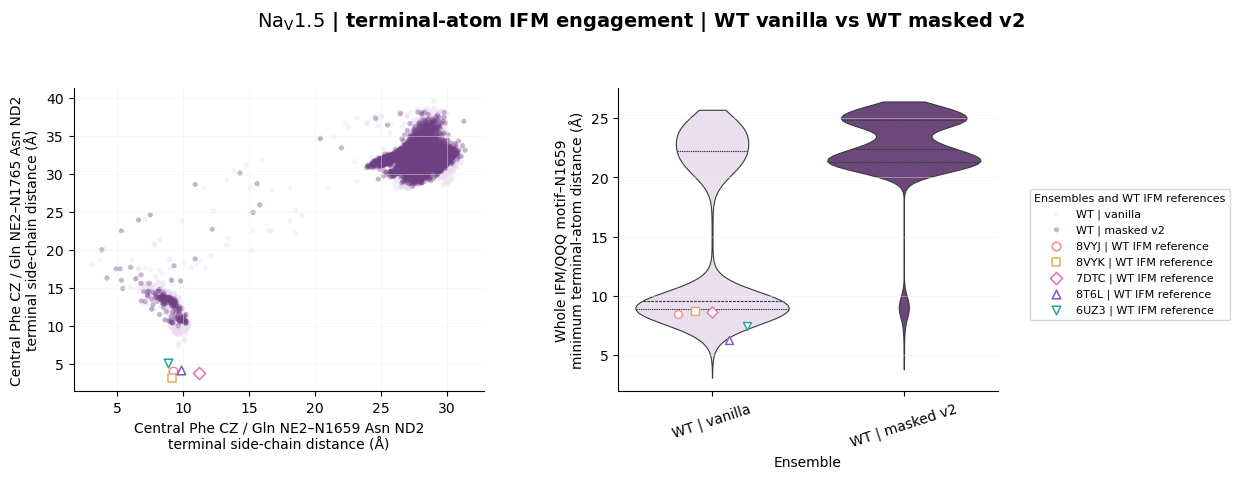

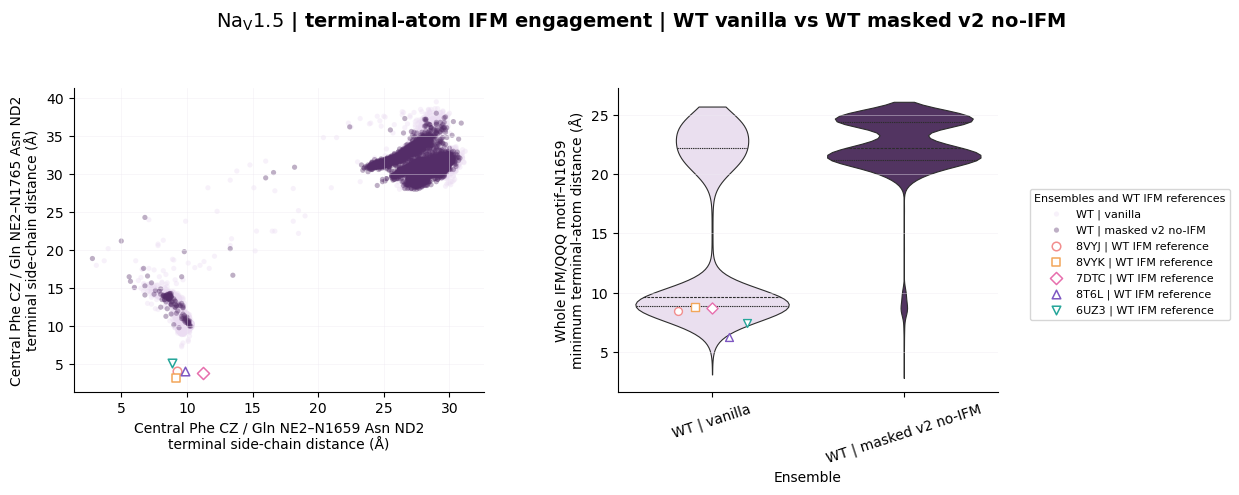

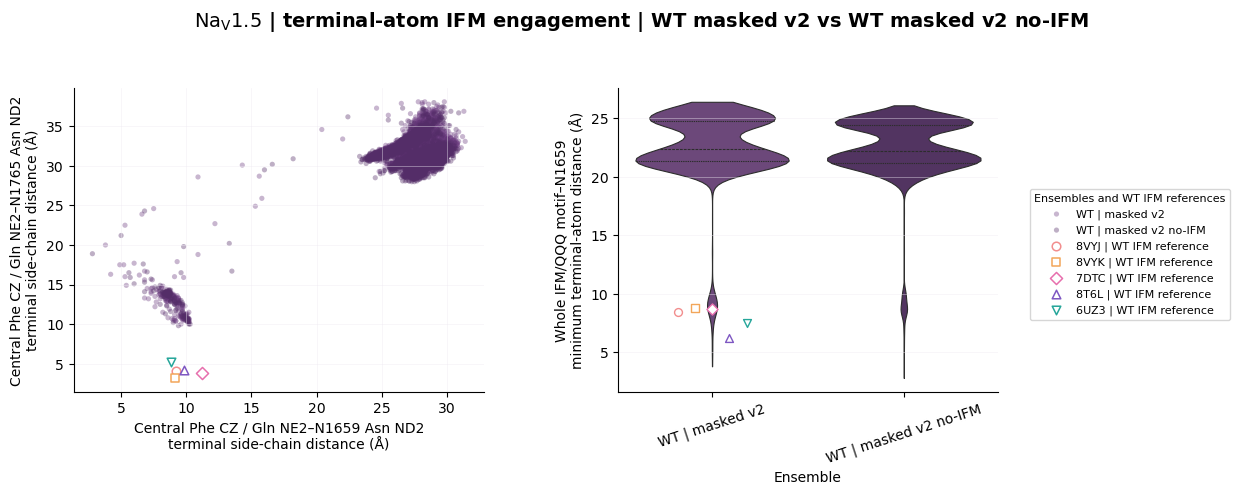

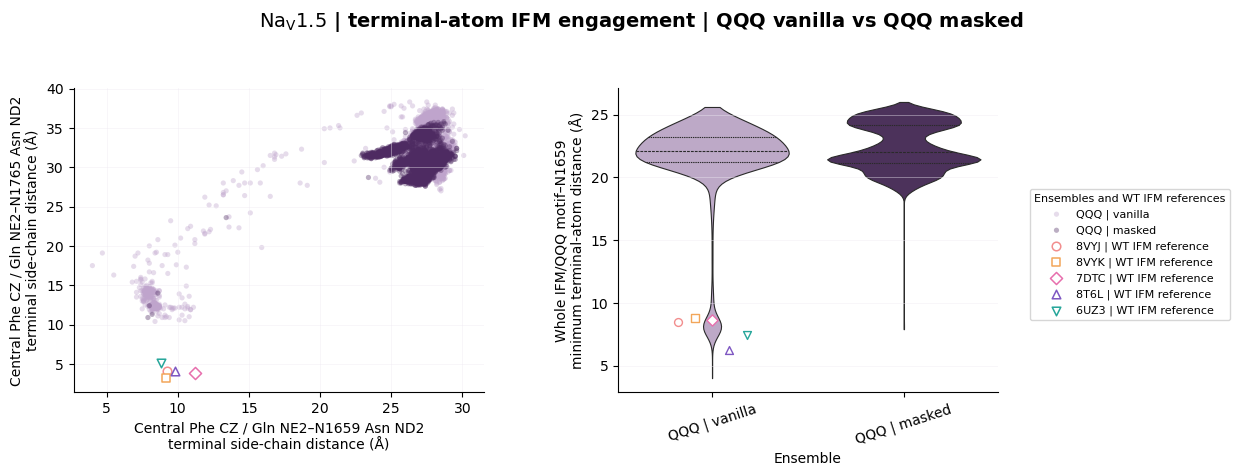

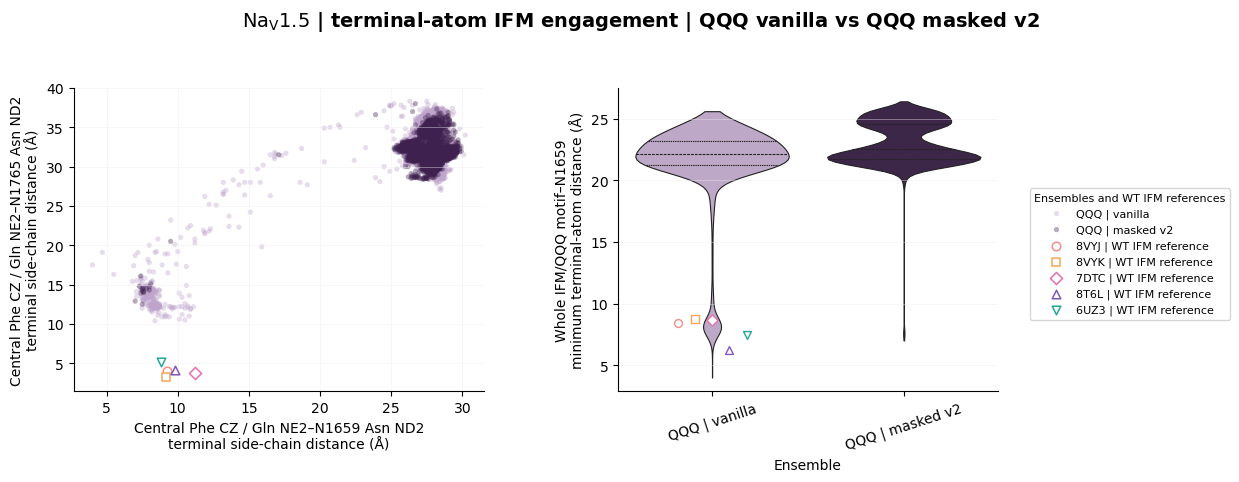

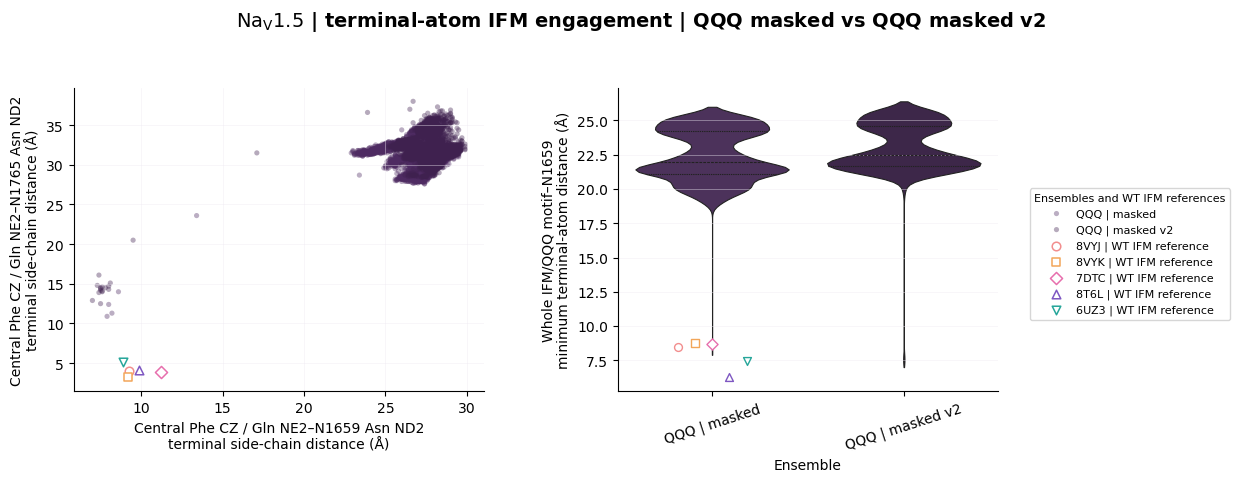

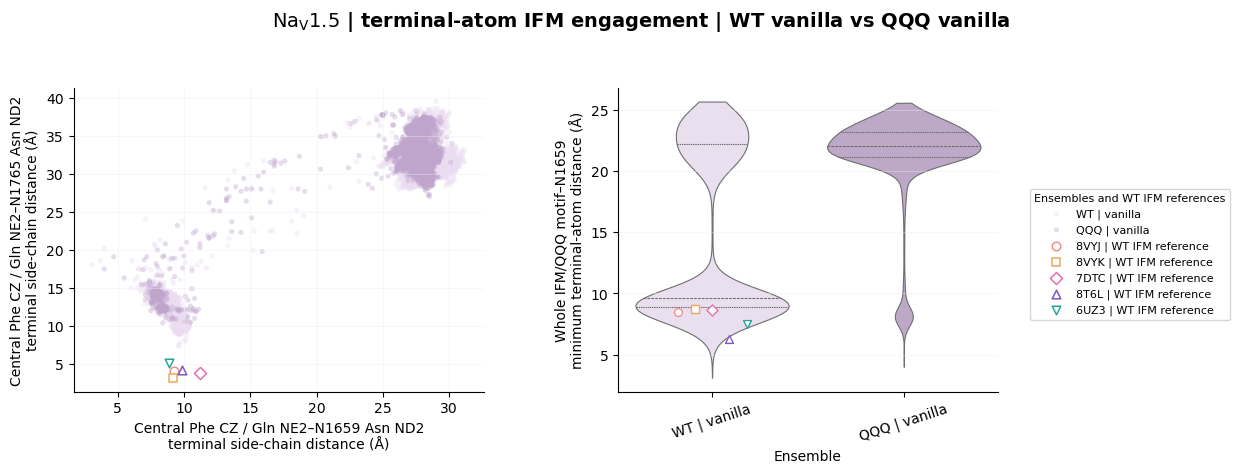

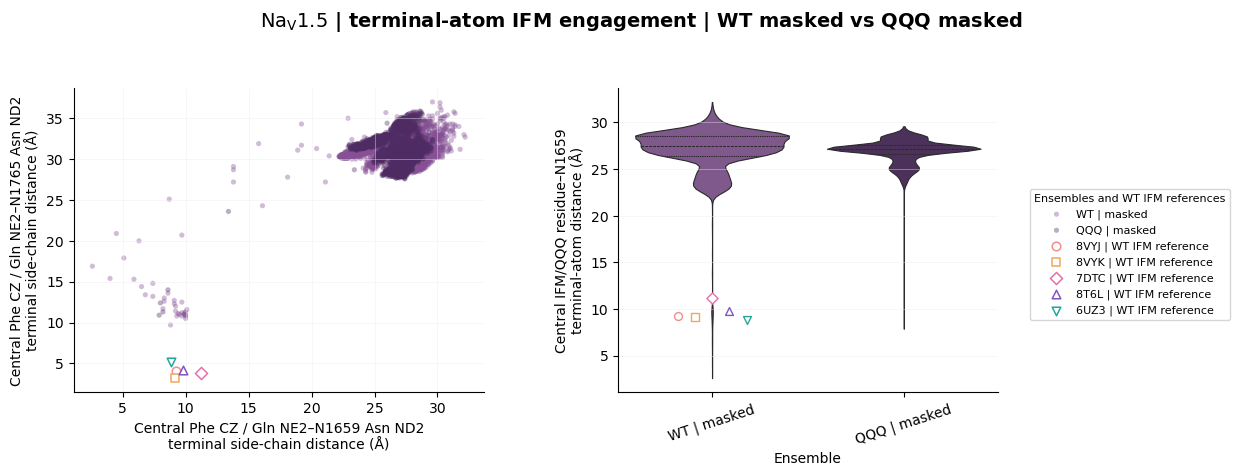

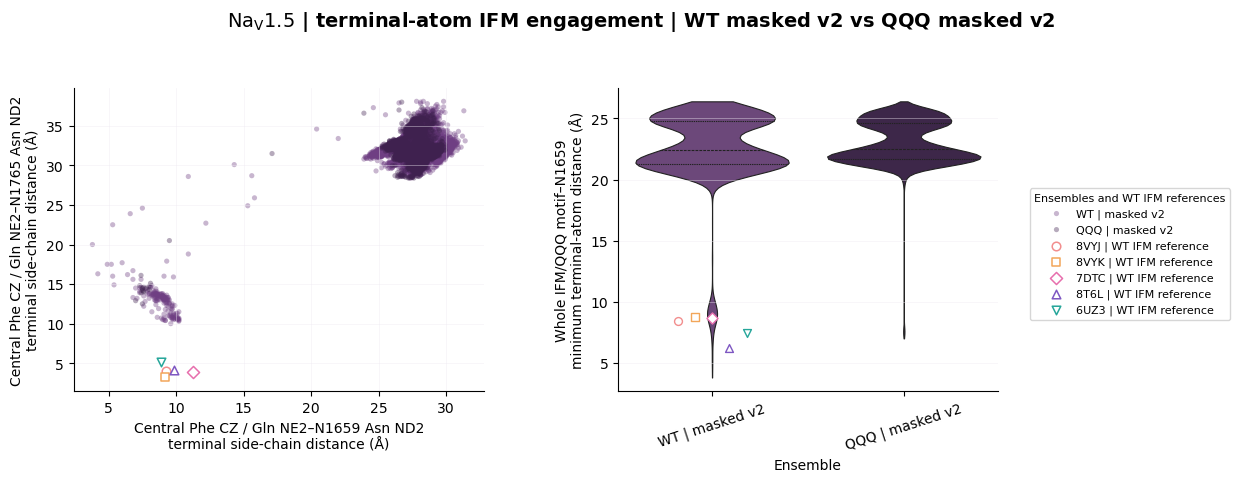

In [10]:
from functools import partial
from shared.nav15_latching import (
    plot_shortest_engagement_contacts as _plot_shortest_engagement_contacts,
)
plot_shortest_engagement_contacts = partial(
    _plot_shortest_engagement_contacts,
    experimental_distances=EXPERIMENTAL_SHORTEST_IFM_DISTANCES,
    ensemble_colors=ENSEMBLE_COLORS,
)

for ensemble_a, ensemble_b in IFM_ENGAGEMENT_COMPARISONS:
    axes = plot_shortest_engagement_contacts(shortest_ifm_df, ensemble_a, ensemble_b)
    slug = f'{ensemble_a}_vs_{ensemble_b}'.lower().replace(' | ', '_').replace(' ', '_').replace('–', '-')
    axes[0].figure.savefig(engagement_figure_dir/f'nav15_ifm_terminal_atom_{slug}.png', dpi=400, bbox_inches='tight')


### Interpretation guardrail
A separated cluster can support sampling of different IFM-contact geometries, but neither Cα coordinates nor terminal side-chain contacts alone establish open-pore gating or causal electromechanical coupling. An engaged assignment is strongest when the backbone and side-chain coordinates agree. Check the intracellular gate and pore-radius coordinates alongside both representations before assigning an open state. The 7FBS QQQ structure does not contain resolved canonical motif coordinates and is therefore not assigned fabricated experimental values.
